In [70]:
!pip install pandas openpyxl

In [71]:
import pandas as pd

In [72]:
import numpy as np

In [73]:
import matplotlib.pyplot as plt

In [74]:
import zipfile

In [75]:
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side

In [76]:
from openpyxl import load_workbook

In [77]:
from io import StringIO

In [78]:
# Dados
dados = StringIO("""data,temperatura_c,nivel_rio_m,ndvi
2025-01-01,32.5,4.2,0.65
2025-01-02,33.1,4.3,0.67
2025-01-03,34.0,,0.66
2025-01-04,35.2,4.5,
2025-01-05,36.0,4.7,0.70
2025-01-06,35.5,4.8,0.72
2025-01-07,34.8,,0.71
2025-01-08,33.9,4.6,0.69
2025-01-09,32.7,4.4,
2025-01-10,31.8,4.3,0.66
""")

In [79]:
df = pd.read_csv(dados)

In [80]:
media = df.mean(numeric_only=True)
df = df.fillna(media)

In [81]:
df['data'] = pd.to_datetime(df['data'], format='%Y-%m-%d')

In [82]:
df = df.sort_values('data')

In [83]:
medias = df.mean(numeric_only=True)

In [84]:
print(medias)

temperatura_c    33.9500
nivel_rio_m       4.4750
ndvi              0.6825
dtype: float64


In [85]:
# Excel
df.to_excel("resultado.xlsx", index=False)

wb = load_workbook("resultado.xlsx")
ws = wb.active

# Estilo da Tabela

header_fill = PatternFill(start_color="2E75B6", end_color="2E75B6", fill_type="solid")
header_font = Font(bold=True, color="FFFFFF")
linha_fill_par = PatternFill(start_color="D9E1F2", end_color="D9E1F2", fill_type="solid")
linha_fill_impar = PatternFill(start_color="FFFFFF", end_color="FFFFFF", fill_type="solid")
borda = Border(
    left=Side(style="thin"),
    right=Side(style="thin"),
    top=Side(style="thin"),
    bottom=Side(style="thin")
)

num_colunas = len(df.columns)


for col in range(1, num_colunas + 1):
    celula = ws.cell(row=1, column=col)
    celula.font = header_font
    celula.fill = header_fill
    celula.alignment = Alignment(horizontal="center")
    celula.border = borda


for row in range(2, len(df) + 2):
    for col in range(1, num_colunas + 1):
        celula = ws.cell(row=row, column=col)
        if row % 2 == 0:
            celula.fill = linha_fill_par
        else:
            celula.fill = linha_fill_impar
        celula.alignment = Alignment(horizontal="center")
        celula.border = borda


larguras = {"data": 15, "temperatura_c": 18, "nivel_rio_m": 18, "ndvi": 10}
for i, coluna in enumerate(df.columns, start=1):
    ws.column_dimensions[ws.cell(row=1, column=i).column_letter].width = larguras.get(coluna, 15)

In [86]:
# Tabela de Médias
linha_inicio = len(df) + 3

header_fill = PatternFill(start_color="2E75B6", end_color="2E75B6", fill_type="solid")
header_font = Font(bold=True, color="FFFFFF")

ws.cell(row=linha_inicio, column=1, value="Variável").font = header_font
ws.cell(row=linha_inicio, column=1).fill = header_fill
ws.cell(row=linha_inicio, column=1).alignment = Alignment(horizontal="center")

ws.cell(row=linha_inicio, column=2, value="Média").font = header_font
ws.cell(row=linha_inicio, column=2).fill = header_fill
ws.cell(row=linha_inicio, column=2).alignment = Alignment(horizontal="center")

nomes = {
    "temperatura_c": "Temperatura (°C)",
    "nivel_rio_m": "Nível do Rio (m)",
    "ndvi": "NDVI"
}

linha_fill = PatternFill(start_color="D9E1F2", end_color="D9E1F2", fill_type="solid")

for i, (col, valor) in enumerate(medias.items()):
    linha = linha_inicio + 1 + i
    ws.cell(row=linha, column=1, value=nomes.get(col, col))
    ws.cell(row=linha, column=2, value=round(valor, 4))
    if i % 2 == 0:
        ws.cell(row=linha, column=1).fill = linha_fill
        ws.cell(row=linha, column=2).fill = linha_fill

ws.column_dimensions['A'].width = 20
ws.column_dimensions['B'].width = 15

wb.save("resultado.xlsx")

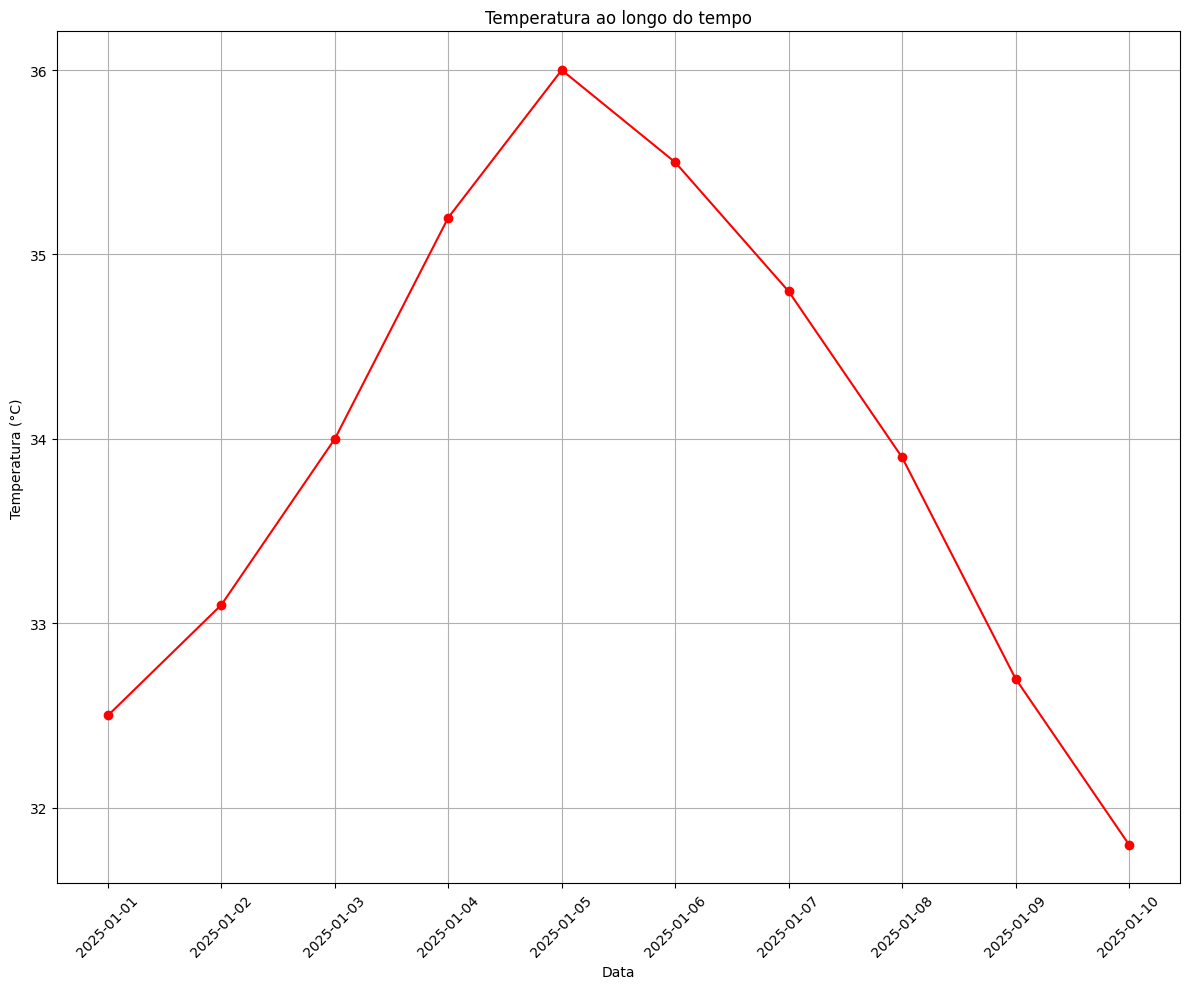

In [87]:
# Gráfico 1: Temperatura
plt.figure(figsize=(12,10))
plt.plot(df['data'], df['temperatura_c'], color='red', marker='o')
plt.title("Temperatura ao longo do tempo")
plt.xlabel("Data")
plt.ylabel("Temperatura (°C)")
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.savefig("grafico_temperatura.png", dpi=150, bbox_inches='tight')
plt.show()


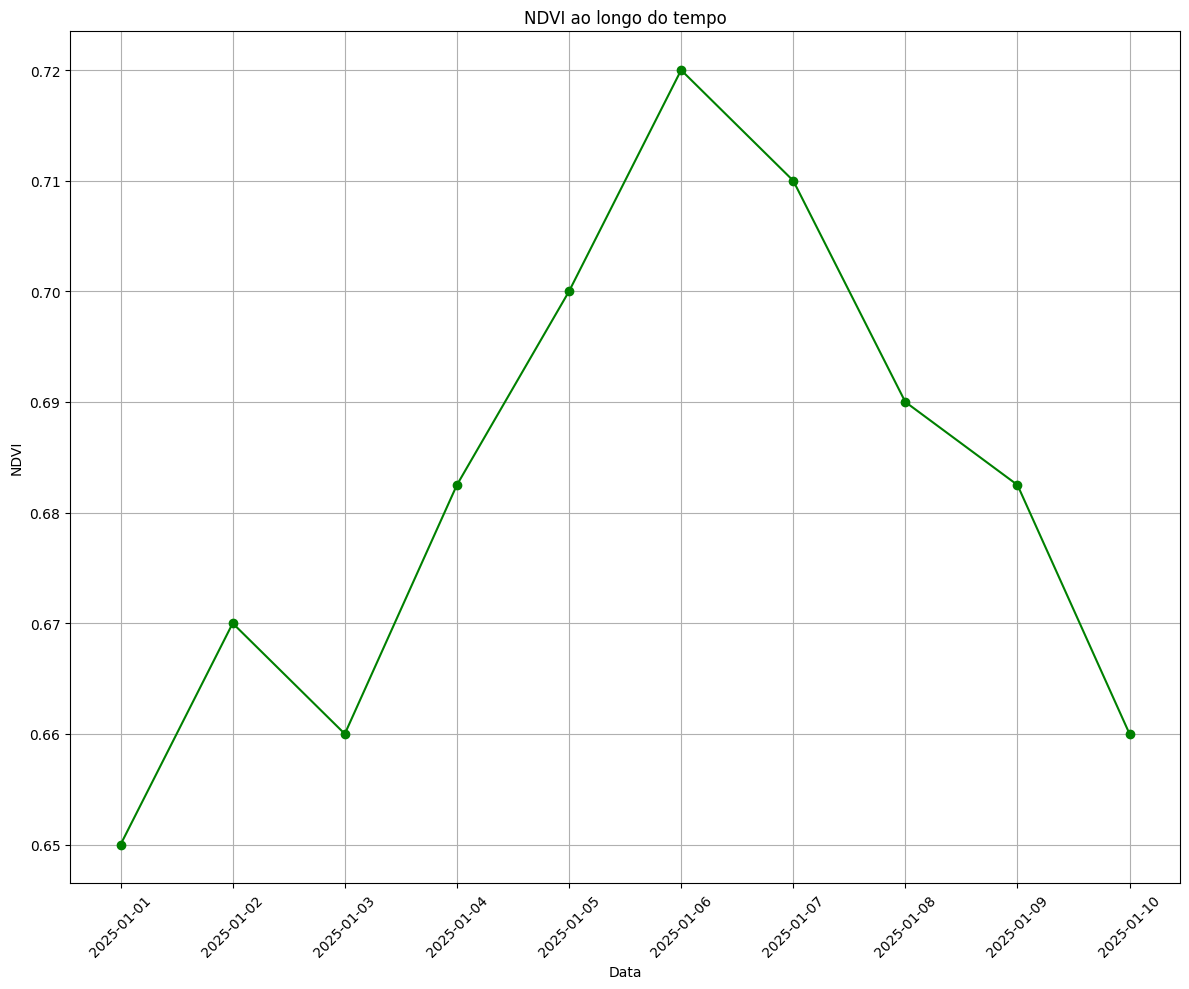

In [88]:
# Gráfico 2: NDVI
plt.figure(figsize=(12,10))
plt.plot(df['data'], df['ndvi'], color='green', marker='o')
plt.title("NDVI ao longo do tempo")
plt.xlabel("Data")
plt.ylabel("NDVI")
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.savefig("grafico_ndvi.png", dpi=150, bbox_inches='tight')
plt.show()


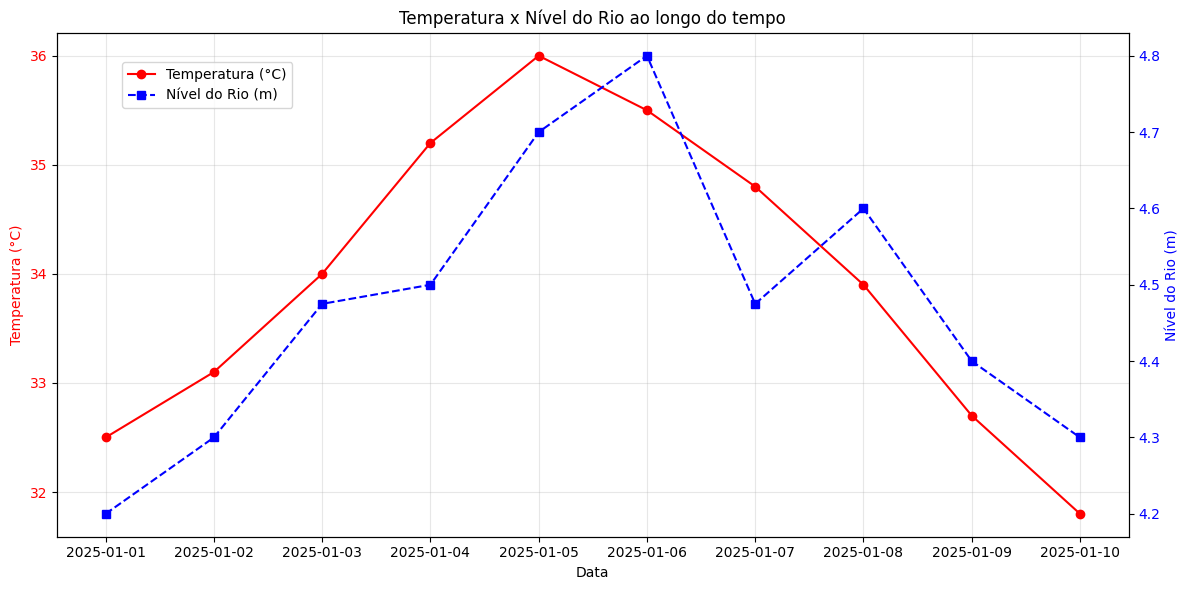

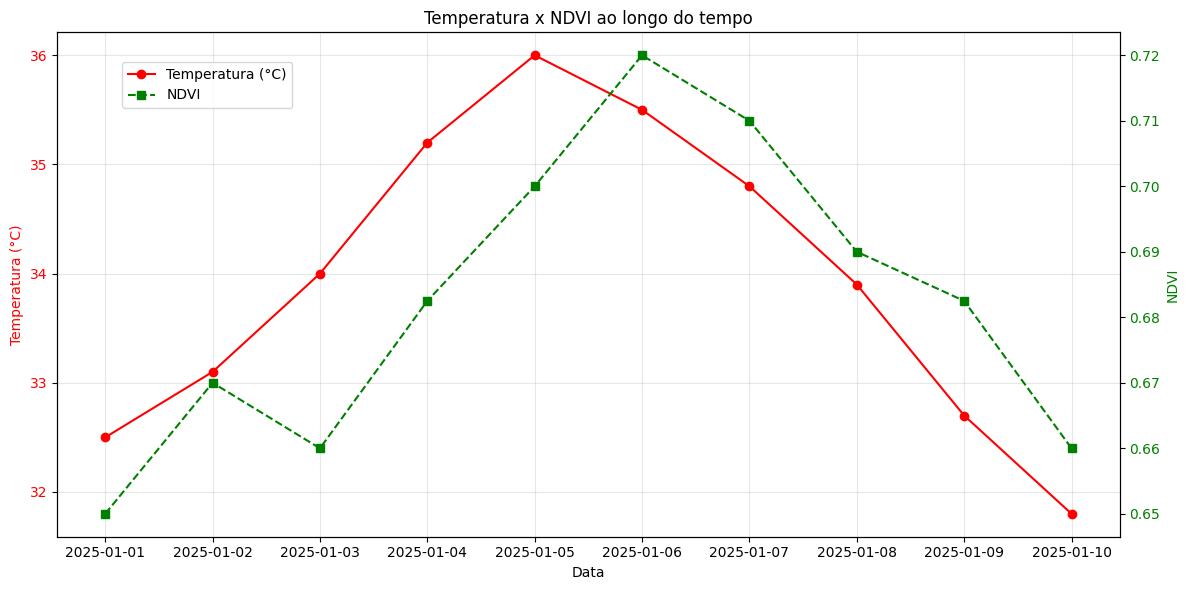

In [89]:
# Gráfico 3: Temperatura X Npivel do Rio
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(df['data'], df['temperatura_c'], color='red', marker='o', label='Temperatura (°C)')
ax1.set_xlabel("Data")
ax1.set_ylabel("Temperatura (°C)", color='red')
ax1.tick_params(axis='y', labelcolor='red')

ax2 = ax1.twinx()
ax2.plot(df['data'], df['nivel_rio_m'], color='blue', marker='s', linestyle='--', label='Nível do Rio (m)')
ax2.set_ylabel("Nível do Rio (m)", color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title("Temperatura x Nível do Rio ao longo do tempo")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.xticks(rotation=45)
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("grafico_linhas_duplas.png", dpi=150, bbox_inches='tight')
plt.show()

# --- Gráfico 4: Temperatura x NDVI
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(df['data'], df['temperatura_c'], color='red', marker='o', label='Temperatura (°C)')
ax1.set_xlabel("Data")
ax1.set_ylabel("Temperatura (°C)", color='red')
ax1.tick_params(axis='y', labelcolor='red')

ax2 = ax1.twinx()
ax2.plot(df['data'], df['ndvi'], color='green', marker='s', linestyle='--', label='NDVI')
ax2.set_ylabel("NDVI", color='green')
ax2.tick_params(axis='y', labelcolor='green')

plt.title("Temperatura x NDVI ao longo do tempo")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.xticks(rotation=45)
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("grafico_temp_ndvi.png", dpi=150, bbox_inches='tight')
plt.show()

correlacao = df['temperatura_c'].corr(df['nivel_rio_m'])

In [90]:
print("=== DADOS TRATADOS ===")
print(df)

print("\n=== MÉDIAS ===")
print(medias)

print(f"\n=== CORRELAÇÃO Temperatura x Nível do Rio ===")
print(f"r = {correlacao:.2f}")

=== DADOS TRATADOS ===
        data  temperatura_c  nivel_rio_m    ndvi
0 2025-01-01           32.5        4.200  0.6500
1 2025-01-02           33.1        4.300  0.6700
2 2025-01-03           34.0        4.475  0.6600
3 2025-01-04           35.2        4.500  0.6825
4 2025-01-05           36.0        4.700  0.7000
5 2025-01-06           35.5        4.800  0.7200
6 2025-01-07           34.8        4.475  0.7100
7 2025-01-08           33.9        4.600  0.6900
8 2025-01-09           32.7        4.400  0.6825
9 2025-01-10           31.8        4.300  0.6600

=== MÉDIAS ===
temperatura_c    33.9500
nivel_rio_m       4.4750
ndvi              0.6825
dtype: float64

=== CORRELAÇÃO Temperatura x Nível do Rio ===
r = 0.85


In [91]:
with zipfile.ZipFile("resultado_final.zip", "w") as zipf:
    zipf.write("resultado.xlsx")
    zipf.write("grafico_temperatura.png")
    zipf.write("grafico_ndvi.png")
    zipf.write("grafico_linhas_duplas.png")
    zipf.write("grafico_temp_ndvi.png")  # ✅ linha nova

In [92]:
from google.colab import files
files.download("resultado_final.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>